In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

<H1> Load / Understand observation 

<H4> loading .h5 file into waterfall object

In [66]:
from blimpy import Waterfall

file_path = "../data/raw/spliced_blc0001020304050607_guppi_57635_35657_Gj144_0005.gpuspec.0002.h5"

obs = Waterfall(file_path)

obs.info()


--- File Info ---
DIMENSION_LABELS :   ['frequency' 'feed_id' 'time']
        az_start :                              0.0
       data_type :                                1
            fch1 :                2802.83203125 MHz
            foff :         -0.00286102294921875 MHz
      machine_id :                               20
           nbits :                               32
          nchans :                           351232
            nifs :                                1
     source_name :                            Gj144
         src_dej :                     -9:13:11.007
         src_raj :                       3:32:54.68
    telescope_id :                                6
           tsamp :               1.0737418239999998
   tstart (ISOT) :          2016-09-04T09:54:17.000
    tstart (MJD) :                57635.41269675926
        za_start :                              0.0

Num ints in file :                              273
      File shape :       (273, np.int64(1), 

In [67]:
signal = obs.data[:,0,:]

freqs, _ = obs.grab_data()

print(f'Signal Shape: {signal.shape}')

print(f'freqs shape: {freqs.shape}')

Signal Shape: (273, 351232)
freqs shape: (351232,)


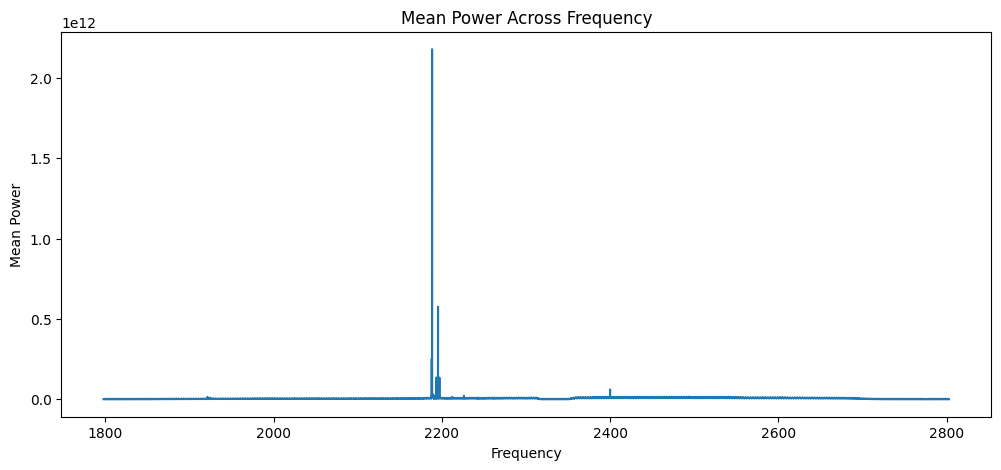

In [68]:
mean_power = signal.mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(freqs, mean_power)
plt.xlabel("Frequency")
plt.ylabel("Mean Power")
plt.title("Mean Power Across Frequency")
plt.show()
plt.close('all')

Huge spike in Mean Power right before the 2200 Mhz. Investigating it

In [69]:
max_freq_index = np.argmax(mean_power)
max_freq = freqs[max_freq_index]

print(np.max(mean_power))
print(max_freq_index)
print(max_freq)

2.1783675e+12
214746
2188.4387969970703


<H1> Temporal Analysis
<H4> What does this candidate do over time?

In [70]:
# Grab all time (273) and only the frequency column with the largest frequency
max_freq_power = signal[:,max_freq_index]

print(max_freq_power.shape)

(273,)


In [71]:
tsamp = obs.header['tsamp']
tsamp_array = np.arange(len(max_freq_power)) * tsamp
print(tsamp_array)
print(tsamp_array.shape)

[  0.           1.07374182   2.14748365   3.22122547   4.2949673
   5.36870912   6.44245094   7.51619277   8.58993459   9.66367642
  10.73741824  11.81116006  12.88490189  13.95864371  15.03238554
  16.10612736  17.17986918  18.25361101  19.32735283  20.40109466
  21.47483648  22.5485783   23.62232013  24.69606195  25.76980378
  26.8435456   27.91728742  28.99102925  30.06477107  31.1385129
  32.21225472  33.28599654  34.35973837  35.43348019  36.50722202
  37.58096384  38.65470566  39.72844749  40.80218931  41.87593114
  42.94967296  44.02341478  45.09715661  46.17089843  47.24464026
  48.31838208  49.3921239   50.46586573  51.53960755  52.61334938
  53.6870912   54.76083302  55.83457485  56.90831667  57.9820585
  59.05580032  60.12954214  61.20328397  62.27702579  63.35076762
  64.42450944  65.49825126  66.57199309  67.64573491  68.71947674
  69.79321856  70.86696038  71.94070221  73.01444403  74.08818586
  75.16192768  76.2356695   77.30941133  78.38315315  79.45689498
  80.5306368 

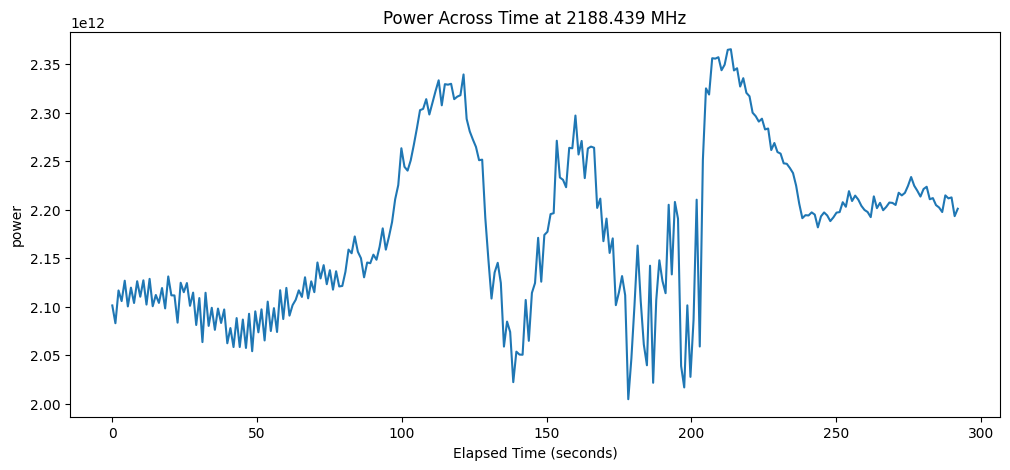

In [72]:
# plot time array again frequency array 
plt.figure(figsize=(12, 5))
plt.plot(tsamp_array, max_freq_power)
plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("power")
plt.title(f"Power Across Time at {max_freq:.3f} MHz")
plt.show()
plt.close('all')

In [73]:
# Define local frequency neighborhood
freq_range = 0.1

lower_freq = max_freq - freq_range
upper_freq = max_freq + freq_range

freq_mask = (freqs >= lower_freq) & (freqs <= upper_freq)

print(freq_mask.shape)
print(freq_mask.sum())

(351232,)
69


In [74]:
spectrogram_region = signal[:, freq_mask]
print(spectrogram_region[:1])
print(spectrogram_region.shape)

[[1.98622618e+10 2.06159380e+10 2.08191263e+10 2.07844495e+10
  2.17670738e+10 2.19190682e+10 2.23787479e+10 2.27159347e+10
  2.21768704e+10 2.28560445e+10 2.40614543e+10 2.41171640e+10
  2.41489183e+10 2.59625370e+10 2.52855808e+10 2.83236516e+10
  3.02062797e+10 3.05789215e+10 4.12478505e+10 5.81116109e+10
  9.30885059e+10 7.35141642e+10 1.02804382e+11 1.21775596e+11
  1.63814572e+11 2.15524426e+11 2.25777402e+11 2.57885995e+11
  3.53620132e+11 6.11345695e+11 1.15432279e+12 1.65188193e+12
  1.65133405e+12 1.85620470e+12 2.10116674e+12 1.93023469e+12
  2.36693514e+12 2.68445182e+12 1.45889690e+12 7.73598675e+11
  6.20069257e+11 7.57948547e+11 4.45424009e+11 4.46464360e+11
  3.49790110e+11 2.48930763e+11 1.34222520e+11 1.17177524e+11
  1.12485122e+11 1.18450455e+11 8.65874330e+10 8.22954148e+10
  7.17976207e+10 4.67524772e+10 3.29774346e+10 2.65789174e+10
  2.47948022e+10 2.36157133e+10 2.40238715e+10 2.48071332e+10
  2.38408765e+10 2.45847286e+10 2.36717507e+10 2.26639073e+10
  2.1998

### Local prominence / detection threshold

At each time sample, compare the candidate's power with the nearby
frequency background.

This tells us whether the candidate is unusually strong relative
to its local environment, rather than merely strong in absolute terms.

In [75]:
local_mean_power = np.mean(spectrogram_region, axis=1)
local_std_power = np.std(spectrogram_region, axis=1)

temporal_z = (max_freq_power - local_mean_power) / local_std_power
print(temporal_z.shape)

(273,)


### Persistence and continuous detection

Convert the local-significance measurements into a Boolean detection
sequence using a 3σ threshold.

Use that sequence to measure:
- how often the candidate is detected
- how many separate detection events occur
- how long those detections persist continuously

In [76]:
temporal_z_mask = temporal_z >= 3
temporal_z_true = np.sum(temporal_z_mask)

persistence = temporal_z_true/temporal_z.shape[0]
print(persistence)

0.6190476190476191


In [77]:
current_run = 0
run_lengths = []

for b_value in temporal_z_mask:
    if b_value:
        current_run += 1
    else:
        if current_run:
            run_lengths.append(current_run)
            current_run = 0

if current_run:
    run_lengths.append(current_run)

print(run_lengths)
print(len(run_lengths))

[1, 1, 36, 3, 31, 3, 1, 8, 1, 1, 83]
11


In [78]:
# Run duration: The continuous amount 
# of time a candidate remains above the detection threshold during one detection event.
run_durations = np.array(run_lengths) * tsamp
print(run_durations)

[ 1.07374182  1.07374182 38.65470566  3.22122547 33.28599654  3.22122547
  1.07374182  8.58993459  1.07374182  1.07374182 89.12057139]


In [79]:
#longest continuous detection
longest_duration = np.max(run_durations)
print(longest_duration)

89.12057139199999


In [80]:
number_of_runs = len(run_durations)
mean_run_duration = np.mean(run_durations)
longest_duration = np.max(run_durations)

print(f"Number of runs: {number_of_runs}")
print(f"Mean run duration: {mean_run_duration:.2f} seconds")
print(f"Longest run duration: {longest_duration:.2f} seconds")

Number of runs: 11
Mean run duration: 16.50 seconds
Longest run duration: 89.12 seconds


The candidate’s longest continuous ≥3σ detection lasted about 89.12 seconds.

Persistence<br>
→ What fraction of the observation was the candidate ≥3σ?<br>
→ ~61.9%<br><br>

Number of runs<br>
→ How many separate continuous detection events occurred?<br>
→ 11<br><br>

Longest run duration<br>
→ What was the longest uninterrupted ≥3σ detection?<br>
→ ~89.12 seconds<br><br>

Mean run duration<br>
→ How long did a continuous detection last on average?<br>
→ ~16.50 seconds

<H1> Spectral Analysis
<H4> What does it look like across frequency?

In [81]:
#matching frequency axis array for 69 columns using the same mask
region_freqs = freqs[freq_mask]

In [82]:
candidate_region_index = np.argmin(
    np.abs(region_freqs - max_freq)
)

print(candidate_region_index)
print(region_freqs[candidate_region_index])

34
2188.4387969970703


In [83]:
bandwidths = []

for i in range(len(spectrogram_region)):
    if temporal_z_mask[i]:
        profile = spectrogram_region[i]
        # Power of OUR known candidate at this time
        candidate_peak = profile[candidate_region_index]
        half_max = candidate_peak / 2
        half_max_mask = profile >= half_max
        half_max_freqs = region_freqs[half_max_mask]
        fwhm = np.max(half_max_freqs) - np.min(half_max_freqs)
        bandwidths.append(fwhm)

print(bandwidths)
print(len(bandwidths))

[np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.02574920654296875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.02574920654296875), np.float64(0.02574920654296875), np.float64(0.02574920654296875), np.float64(0.02574920654296875), np.float64(0.02574920654296875), np.float64(0.02574920654296875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), np.float64(0.0286102294921875), 

In [84]:
# MHz
bandwidths_arr = np.array(bandwidths)

bandwidths_mean = np.mean(bandwidths_arr)
bandwidths_std = np.std(bandwidths_arr)
bandwidths_min = np.min(bandwidths_arr)
bandwidths_max = np.max(bandwidths_arr)

print(f"Mean bandwidth: {bandwidths_mean}")
print(f"Bandwidth std: {bandwidths_std}")
print(f"Minimum bandwidth: {bandwidths_min}")
print(f"Maximum bandwidth: {bandwidths_max}")

Mean bandwidth: 0.028999599479359282
Bandwidth std: 0.0016741873812355333
Minimum bandwidth: 0.02288818359375
Maximum bandwidth: 0.03147125244140625


SPECTRAL ANALYSIS<br><br>

Question:<br>
How wide is our candidate in frequency?<br><br>

Method:<br>
FWHM, measured only when candidate ≥3σ<br><br>

Results:<br>
Mean bandwidth &emsp;       ~29.00 kHz<br>
Std bandwidth  &emsp;       ~1.67 kHz<br>
Narrowest      &emsp;       ~22.89 kHz<br>
Widest         &emsp;       ~31.47 kHz

<H1>Drift analysis 
<H4>Does its frequency position change over time?

In [85]:
peak_freqs = []
peak_times = []

for i in range(len(spectrogram_region)):
    if temporal_z_mask[i]:
        profile = spectrogram_region[i]

        peak_freq_index = np.argmax(profile)
        peak_freq = region_freqs[peak_freq_index]

        peak_freqs.append(peak_freq)
        peak_times.append(tsamp_array[i])

print(len(peak_freqs))
print(len(peak_times))

169
169


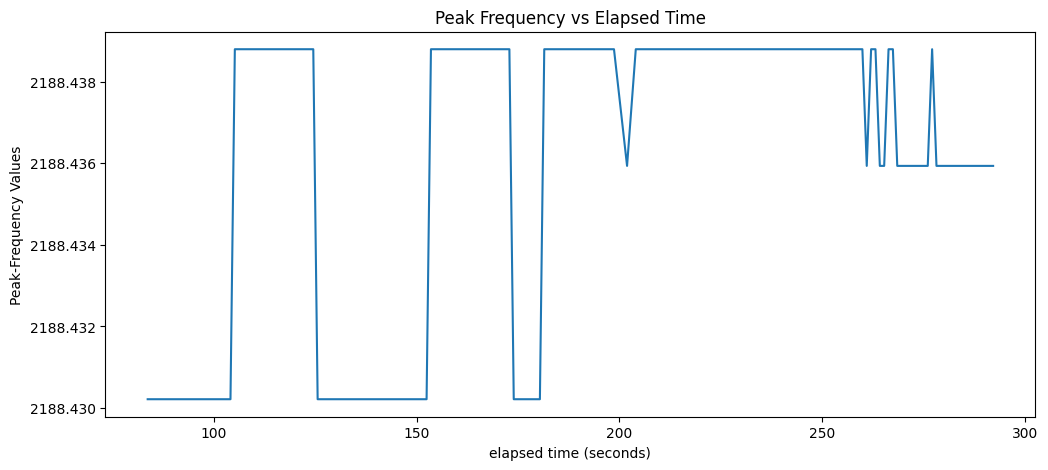

In [86]:
plt.figure(figsize=(12,5))
plt.plot(peak_times, peak_freqs)
plt.xlabel('elapsed time (seconds)')
plt.ylabel('Peak-Frequency Values')
plt.title('Peak Frequency vs Elapsed Time')
plt.show()

In [87]:
# drift_slope is Mhz/s
# polyfit = [slope, intercept] ... (X,y,degree_polynomial)

# np.polyfit() is a NumPy function that fits a polynomial to data.

#slope tell us overall drift rate
drift_slope, intercept = np.polyfit(peak_times, peak_freqs, 1)

print(drift_slope)

2.2545127896134562e-05


In [88]:
drift_hz_per_sec = drift_slope * 1e6
print(drift_hz_per_sec)

22.545127896134563


The candidate’s peak frequency has an overall positive drift rate (linear trend) of approximately +22.55 Hz/s.

In [89]:
# y = mx + b
predicted_freqs = drift_slope * np.array(peak_times) + intercept
print(predicted_freqs)

[2188.43408947 2188.43423472 2188.43428314 2188.43430734 2188.43433155
 2188.43435576 2188.43437997 2188.43440417 2188.43442838 2188.43445259
 2188.4344768  2188.434501   2188.43452521 2188.43454942 2188.43457363
 2188.43459784 2188.43462204 2188.43464625 2188.43467046 2188.43469467
 2188.43471887 2188.43474308 2188.43476729 2188.4347915  2188.4348157
 2188.43483991 2188.43486412 2188.43488833 2188.43491253 2188.43493674
 2188.43496095 2188.43498516 2188.43500937 2188.43503357 2188.43505778
 2188.43508199 2188.4351062  2188.4351304  2188.43517882 2188.43520303
 2188.43522723 2188.43546931 2188.43549352 2188.43551773 2188.43554193
 2188.43556614 2188.43559035 2188.43561456 2188.43563876 2188.43566297
 2188.43568718 2188.43571139 2188.43573559 2188.4357598  2188.43578401
 2188.43580822 2188.43583243 2188.43585663 2188.43588084 2188.43590505
 2188.43592926 2188.43595346 2188.43597767 2188.43600188 2188.43602609
 2188.43605029 2188.4360745  2188.43609871 2188.43612292 2188.43614712
 2188.4

In [90]:
# How far the observed peak frequency is 
# from the frequency predicted by our linear drift model at that time.
#residual = observed frequency - predicted frequency
residuals = peak_freqs - predicted_freqs

# SS_res measures the total squared error 
# between our observed peak frequencies and the linear drift model.
ss_res = np.sum(residuals ** 2)

# How much does the observed data vary around its own mean?
mean_freq = np.mean(peak_freqs)
ss_tot = np.sum((peak_freqs - mean_freq) ** 2)

# R-squared
# This tells us How well does a straight-line 
# frequency-drift model explain the variation in the observed peak frequencies over time?
drift_r2 = 1 - (ss_res / ss_tot)
print(drift_r2)

0.16083194580249305


### Drift Summary
<br>
Linear drift slope:<br>
→ ~+22.55 Hz/s<br><br>

R²:<br>
→ ~0.161<br><br>

Interpretation:<br>
→ The peak frequency has a weak overall positive trend, but only
about 16% of its variation is explained by a linear drift model.
The candidate therefore does not exhibit strong, consistent
linear frequency drift during the observation.

In [91]:
# Convert residuals to Hz
residuals_hz = residuals * 1e6

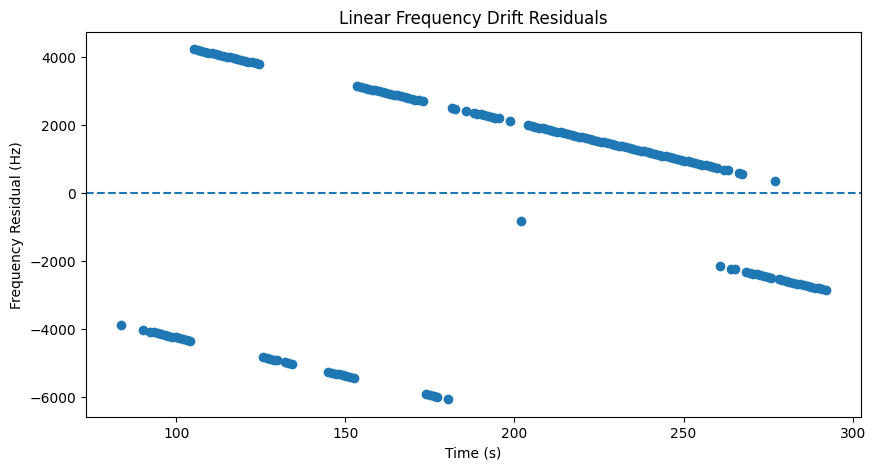

In [92]:
plt.figure(figsize=(10, 5))

plt.scatter(peak_times, residuals_hz)
plt.axhline(0, linestyle="--")

plt.xlabel("Time (s)")
plt.ylabel("Frequency Residual (Hz)")
plt.title("Linear Frequency Drift Residuals")

plt.show()
plt.close('all')

There is an overall positive fitted slope, but the candidate’s frequency behavior is not well described by continuous linear drift. Instead, its measured peak occupies discrete frequency levels/plateaus and changes between them.

### Frequency-bin resolution

Examine whether changes in measured peak frequency correspond to
the discrete frequency resolution of the observation.

In [93]:
unique_peak_freqs = np.unique(peak_freqs)

print("Number of unique peak frequencies:", len(unique_peak_freqs))
print(unique_peak_freqs)

Number of unique peak frequencies: 3
[2188.43021393 2188.43593597 2188.438797  ]


In [94]:
freq_steps = np.diff(unique_peak_freqs)

print(freq_steps)

[0.00572205 0.00286102]


In [95]:
freq_steps_hz = freq_steps * 1e6

print(freq_steps_hz)

[5722.04589844 2861.02294922]


In [96]:
print(freqs[:5])
print(np.diff(freqs[:5]))
print(np.abs(np.diff(freqs[:5])) * 1e6)

[2802.83203125 2802.82917023 2802.8263092  2802.82344818 2802.82058716]
[-0.00286102 -0.00286102 -0.00286102 -0.00286102]
[2861.02294922 2861.02294922 2861.02294922 2861.02294922]


Frequency-bin resolution: The detected peak occupies three unique frequency bins. Adjacent measured peak positions differ by ~2.861 kHz or ~5.722 kHz, corresponding to one or two frequency bins. The dataset’s frequency-bin spacing is ~2.861 kHz. Therefore, the step-like changes in peak frequency are consistent with the discrete frequency resolution of the observation and should not automatically be interpreted as smooth physical frequency drift.

### Sub-bin peak estimation

Because `np.argmax()` can only identify discrete frequency bins,
the measured peak frequency is limited by the spectrogram's
~2.861 kHz bin spacing.

Inspect the peak bin and its immediate neighbors so we can estimate
where the true peak may lie between bins.

In [97]:
detected_indices = np.where(temporal_z_mask)[0]

print(detected_indices[:10])

[78 84 86 87 88 89 90 91 92 93]


In [98]:
time_idx = detected_indices[0]

profile = spectrogram_region[time_idx]
peak_freq_index = np.argmax(profile)

print("Time index:", time_idx)

left_power = profile[peak_freq_index - 1]
peak_power = profile[peak_freq_index]
right_power = profile[peak_freq_index + 1]

print("Left power:", left_power)
print("Peak power:", peak_power)
print("Right power:", right_power)

print("Left freq:", region_freqs[peak_freq_index - 1])
print("Peak freq:", region_freqs[peak_freq_index])
print("Right freq:", region_freqs[peak_freq_index + 1])

Time index: 78
Left power: 2.0180958e+12
Peak power: 2.4485314e+12
Right power: 1.3492815e+12
Left freq: 2188.433074951172
Peak freq: 2188.4302139282227
Right freq: 2188.4273529052734


delta<br>
→ where inside the gap between channels the peak is estimated to sit<br><br>

bin_spacing<br>
→ how many MHz one full channel step represents<br><br>

delta * bin_spacing<br>
→ estimated frequency correction

In [ ]:
delta = 0.5 * (left_power - right_power) / (
    left_power - 2 * peak_power + right_power
)

print(delta)

-0.21861167


In [100]:
bin_spacing = (
    region_freqs[peak_freq_index + 1]
    - region_freqs[peak_freq_index]
)

interpolated_peak_freq = (
    region_freqs[peak_freq_index]
    + delta * bin_spacing
)

print("Delta:", delta)
print("Interpolated peak frequency:", interpolated_peak_freq)

Delta: -0.21861167
Interpolated peak frequency: 2188.430839381235


interpolated value is our estimated location of the actual peak frequency between the discrete frequency channels we measured.

In [101]:
interpolated_peak_freqs = []
interpolated_peak_times = []

for i in range(len(spectrogram_region)):

    if temporal_z_mask[i]:

        profile = spectrogram_region[i]
        peak_freq_index = np.argmax(profile)

        # Edge case: can't do 3-point interpolation at boundaries
        if peak_freq_index == 0 or peak_freq_index == len(profile) - 1:
            interpolated_freq = region_freqs[peak_freq_index]

        else:
            # Powers in the neighboring frequency channels
            y_left = profile[peak_freq_index - 1]
            y_peak = profile[peak_freq_index]
            y_right = profile[peak_freq_index + 1]

            # Estimate peak position as a fraction of one bin
            bin_offset = 0.5 * (y_left - y_right) / (
                y_left - 2 * y_peak + y_right
            )

            # Convert fractional-bin offset into frequency
            bin_spacing = (
                region_freqs[peak_freq_index + 1]
                - region_freqs[peak_freq_index]
            )

            interpolated_freq = (
                region_freqs[peak_freq_index]
                + bin_offset * bin_spacing
            )

        interpolated_peak_freqs.append(interpolated_freq)
        interpolated_peak_times.append(tsamp_array[i])

print(len(interpolated_peak_freqs))
print(interpolated_peak_freqs[:10])

169
[np.float64(2188.430839381235), np.float64(2188.430797595737), np.float64(2188.430816997945), np.float64(2188.4308502570148), np.float64(2188.4308096195696), np.float64(2188.4308277158143), np.float64(2188.430852266032), np.float64(2188.430903994552), np.float64(2188.4309099232496), np.float64(2188.430948078883)]


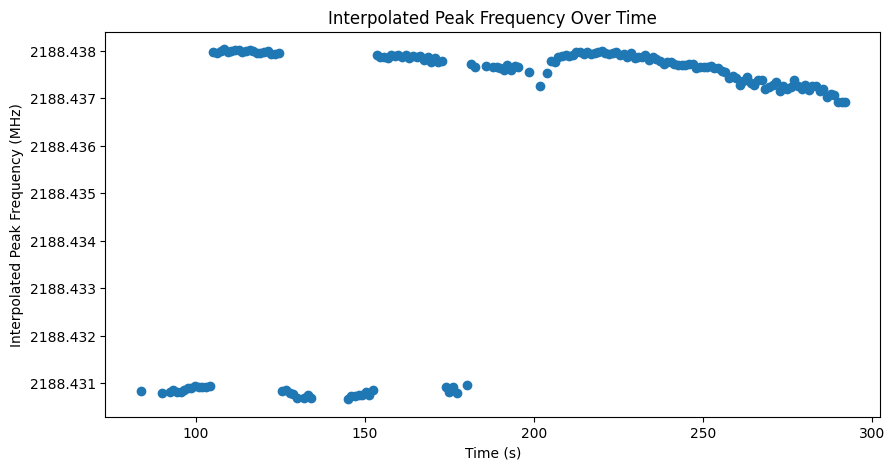

In [103]:
plt.figure(figsize=(10, 5))

plt.scatter(
    interpolated_peak_times,
    interpolated_peak_freqs
)

plt.xlabel("Time (s)")
plt.ylabel("Interpolated Peak Frequency (MHz)")
plt.title("Interpolated Peak Frequency Over Time")

plt.show()
plt.close("all")

The staircase structure in the original peak-frequency plot was partly caused by the ~2.861 kHz frequency-bin resolution. Sub-bin interpolation reveals finer changes in estimated peak position within those bins.

In [104]:
# re-do drift fit with new calculated values
interp_drift_slope, interp_intercept = np.polyfit(interpolated_peak_times,interpolated_peak_freqs,1)

interp_drift_hz_per_sec = interp_drift_slope * 1e6

print("Interpolated drift rate:", interp_drift_hz_per_sec, "Hz/s")

Interpolated drift rate: 23.154243172046584 Hz/s


In [105]:
# Calculate R-squared again
interp_predicted_freqs = (
    interp_drift_slope * np.array(interpolated_peak_times)
    + interp_intercept
)

interp_residuals = (
    np.array(interpolated_peak_freqs)
    - interp_predicted_freqs
)

interp_ss_res = np.sum(interp_residuals ** 2)

interp_mean_freq = np.mean(interpolated_peak_freqs)

interp_ss_tot = np.sum(
    (np.array(interpolated_peak_freqs) - interp_mean_freq) ** 2
)

interp_drift_r2 = 1 - (interp_ss_res / interp_ss_tot)

print("Interpolated R²:", interp_drift_r2)

Interpolated R²: 0.25266008199162626


## 6. Candidate Summary

### Temporal Behavior
- Candidate detected ≥3σ for 61.9% of the observation.
- 11 separate detection runs.
- Mean continuous run duration: 16.50 s.
- Longest continuous detection: 89.12 s.

Interpretation:
The candidate is persistent but intermittent. It appears significantly
above the local background for a majority of the observation, including
one particularly long continuous detection.

### Spectral Behavior
- Mean FWHM bandwidth: ~29.00 kHz.
- Standard deviation: ~1.67 kHz.
- Range: ~22.89–31.47 kHz.

Interpretation:
When detected, the candidate has a relatively stable spectral width of
approximately 29 kHz, with some variation over time.

### Frequency Drift
Discrete-bin estimate:
- Drift rate: +22.55 Hz/s
- R²: 0.161

Sub-bin interpolated estimate:
- Drift rate: +23.15 Hz/s
- R²: 0.253

Interpretation:
The candidate shows an overall positive frequency trend. Sub-bin
interpolation improves the linear fit, but the low R² indicates that
a single linear drift model still explains only a limited portion of
the candidate's frequency behavior.

### Overall Candidate Interpretation

- We cannot identify the physical source from these features alone. What Phase 3 establishes is how the candidate behaves in time and frequency: it is persistent but intermittent, has a relatively stable spectral width, and shows changing peak frequency with only weak-to-moderate evidence for a single linear drift trend.

- The candidate is persistent but intermittent, appearing above the local 3σ threshold for 61.9% of the observation across 11 separate detection runs. Its longest continuous detection is 89.12 seconds. When detected, it has a relatively stable FWHM bandwidth of approximately 29 kHz. Its peak frequency changes over time and shows an overall positive trend of approximately +23 Hz/s after sub-bin interpolation, although the relatively low R² (~0.25) indicates that a single linear drift model does not adequately describe most of its frequency behavior. These measurements characterize the signal’s behavior but do not establish the physical origin of the candidate.